In [20]:
 # 1. Data Loading & Cleaning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt


orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')

print("All datasets loaded successfully!")
print(f"Orders: {orders.shape}")
print(f"Customers: {customers.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Products: {products.shape}")
print(f"Payments: {payments.shape}")
print(f"Reviews: {reviews.shape}")


print("=== ORDERS ===")
print(orders.head(3))
print(orders.shape)

print("\n=== CUSTOMERS ===")
print(customers.head(3))
print(customers.shape)

print("\n=== ORDER ITEMS ===")
print(order_items.head(3))
print(order_items.shape)

print("\n=== PRODUCTS ===")
print(products.head(3))
print(products.shape)

print("\n=== PAYMENTS ===")
print(payments.head(3))
print(payments.shape)

print("\n=== REVIEWS ===")
print(reviews.head(3))
print(reviews.shape)


datasets = {
    'Orders': orders,
    'Customers': customers,
    'Order Items': order_items,
    'Products': products,
    'Payments': payments,
    'Reviews': reviews
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"\n=== {name} ===")
    if missing.empty:
        print("No missing values ✅")
    else:
        print(missing)

# Fix datetime columns
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Fill missing product category
products['product_category_name'] = products['product_category_name'].fillna('Unknown')

# Drop review comment columns (too many missing, not needed)
reviews = reviews.drop(columns=['review_comment_title', 'review_comment_message'])

# Check duplicates
for name, df in datasets.items():
    dups = df.duplicated().sum()
    print(f"{name} duplicates: {dups}")

print("\nCleaning done! ✅")


# Merge orders + customers
df = orders.merge(customers, on='customer_id', how='left')

# Merge with order items
df = df.merge(order_items, on='order_id', how='left')

# Merge with products
df = df.merge(products, on='product_id', how='left')

# Aggregate payments per order then merge
payments_agg = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')
).reset_index()
df = df.merge(payments_agg, on='order_id', how='left')

# Aggregate reviews per order then merge
reviews_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()
df = df.merge(reviews_agg, on='order_id', how='left')

print(f"Master dataframe shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")




# Time columns
df['order_year'] = df['order_purchase_timestamp'].dt.year
df['order_month'] = df['order_purchase_timestamp'].dt.month

# Revenue per item (price + freight)
df['item_revenue'] = df['price'] + df['freight_value']

# Delivery days
df['delivery_days'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.days

# Late flag (1 = late, 0 = on time)
df['is_late'] = (
    df['order_delivered_customer_date'] > df['order_estimated_delivery_date']
).astype(int)

print("Helper columns added ✅")
print(df[['order_year', 'order_month', 'item_revenue', 'delivery_days', 'is_late']].head())


# Check what years we have
print("Year distribution:")
print(df['order_year'].value_counts().sort_index())

print("\n2018 months available:")
print(df[df['order_year'] == 2018]['order_month'].value_counts().sort_index())

# Remove 2016 (incomplete year) and Sep–Oct 2018 (data cutoff)
df_clean = df[
    (df['order_year'] != 2016) &
    ~((df['order_year'] == 2018) & (df['order_month'] >= 9))
]

print(f"\nOriginal rows: {df.shape[0]}")
print(f"Clean rows: {df_clean.shape[0]}")
print(f"Removed: {df.shape[0] - df_clean.shape[0]}")

print("\nYears remaining:")
print(df_clean['order_year'].value_counts().sort_index())

print("\n2018 months remaining:")
print(df_clean[df_clean['order_year'] == 2018]['order_month'].value_counts().sort_index())

All datasets loaded successfully!
Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)
=== ORDERS ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimat

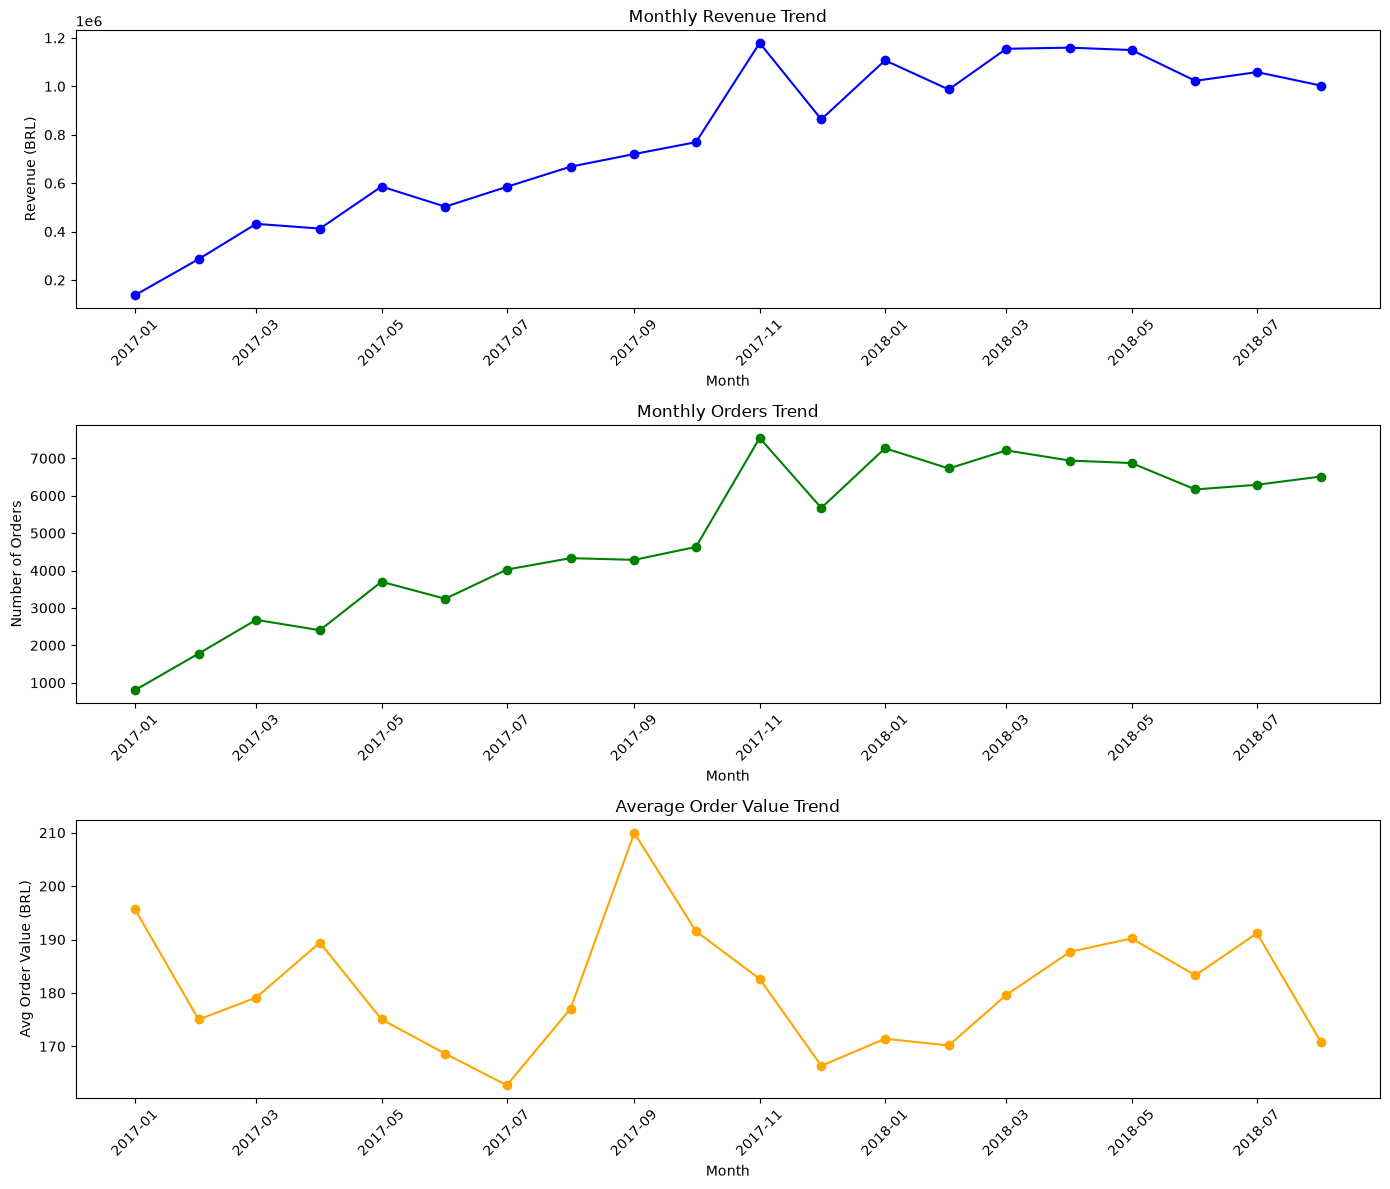

   year_month  total_revenue  total_orders  avg_order_value
0  2017-01-01      137188.49           800       195.668385
1  2017-02-01      286280.62          1780       175.025991
2  2017-03-01      432048.59          2682       179.131282
3  2017-04-01      412422.24          2404       189.429570
4  2017-05-01      586190.95          3700       175.051985
5  2017-06-01      502963.04          3245       168.621263
6  2017-07-01      584971.62          4026       162.718429
7  2017-08-01      668204.60          4331       177.067375
8  2017-09-01      720398.91          4285       209.951876
9  2017-10-01      769312.37          4631       191.551630
10 2017-11-01     1179143.77          7544       182.626648
11 2017-12-01      863547.23          5673       166.365006
12 2018-01-01     1107301.89          7269       171.411958
13 2018-02-01      986908.96          6728       170.161006
14 2018-03-01     1155126.82          7211       179.617172
15 2018-04-01     1159698.04          69

In [19]:
## 2. Revenue Analysis

monthly_revenue = df_clean.groupby(['order_year', 'order_month']).agg(
    total_revenue=('item_revenue', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_order_value=('total_payment', 'mean')
).reset_index()

monthly_revenue['year_month'] = pd.to_datetime(
    monthly_revenue['order_year'].astype(str) + '-' +
    monthly_revenue['order_month'].astype(str)
)

monthly_revenue = monthly_revenue.sort_values('year_month')

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(monthly_revenue['year_month'],
             monthly_revenue['total_revenue'],
             color='blue', marker='o')
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (BRL)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_revenue['year_month'],
             monthly_revenue['total_orders'],
             color='green', marker='o')
axes[1].set_title('Monthly Orders Trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(monthly_revenue['year_month'],
             monthly_revenue['avg_order_value'],
             color='orange', marker='o')
axes[2].set_title('Average Order Value Trend')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Avg Order Value (BRL)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(monthly_revenue[['year_month', 'total_revenue', 'total_orders', 'avg_order_value']])

=== TOP 10 CATEGORIES BY ORDERS ===
     product_category_name  total_orders  total_revenue   avg_price
14         cama_mesa_banho          9412     1241075.14   93.320401
12            beleza_saude          8791     1435611.23  130.366344
33           esporte_lazer          7701     1152729.37  114.209618
45  informatica_acessorios          6671     1057532.31  116.648091
55        moveis_decoracao          6397      895323.28   87.583994
73   utilidades_domesticas          5875      776855.23   90.759722
67      relogios_presentes          5619     1302073.57  200.742639
71               telefonia          4189      394174.28   71.263333
9               automotivo          3886      683126.76  139.921113
13              brinquedos          3861      556386.47  117.232643

=== TOP 10 CATEGORIES BY REVENUE ===
     product_category_name  total_orders  total_revenue   avg_price
12            beleza_saude          8791     1435611.23  130.366344
67      relogios_presentes          5619  

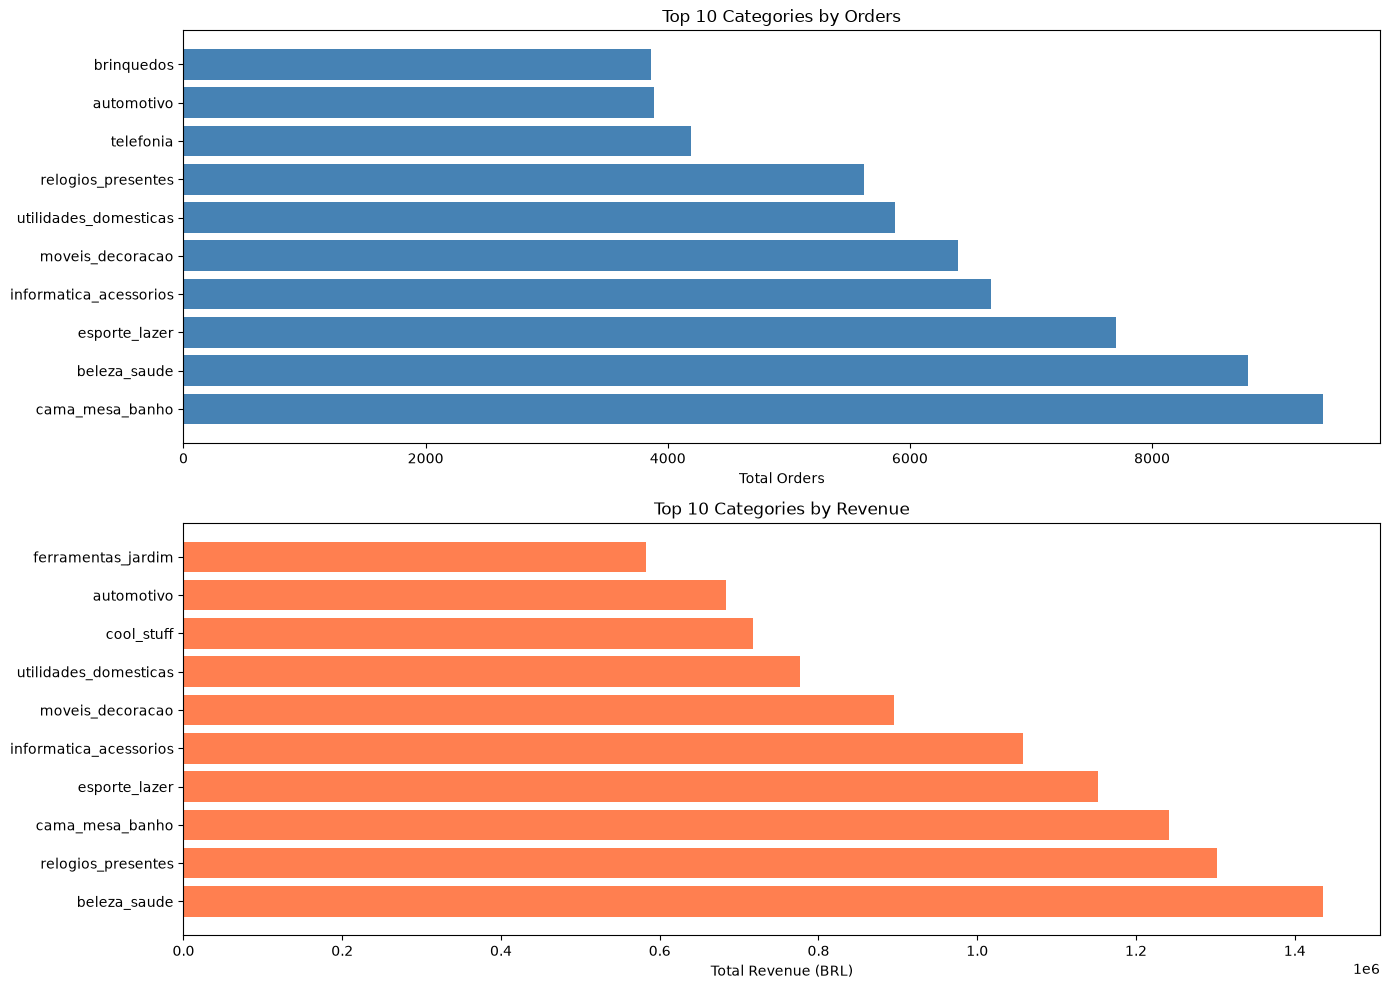

  product_category_name  total_orders  total_revenue   avg_price  avg_freight
0          beleza_saude          8791     1435611.23  130.366344    18.881107
1       cama_mesa_banho          9412     1241075.14   93.320401    18.417705
2         esporte_lazer          7701     1152729.37  114.209618    19.486667


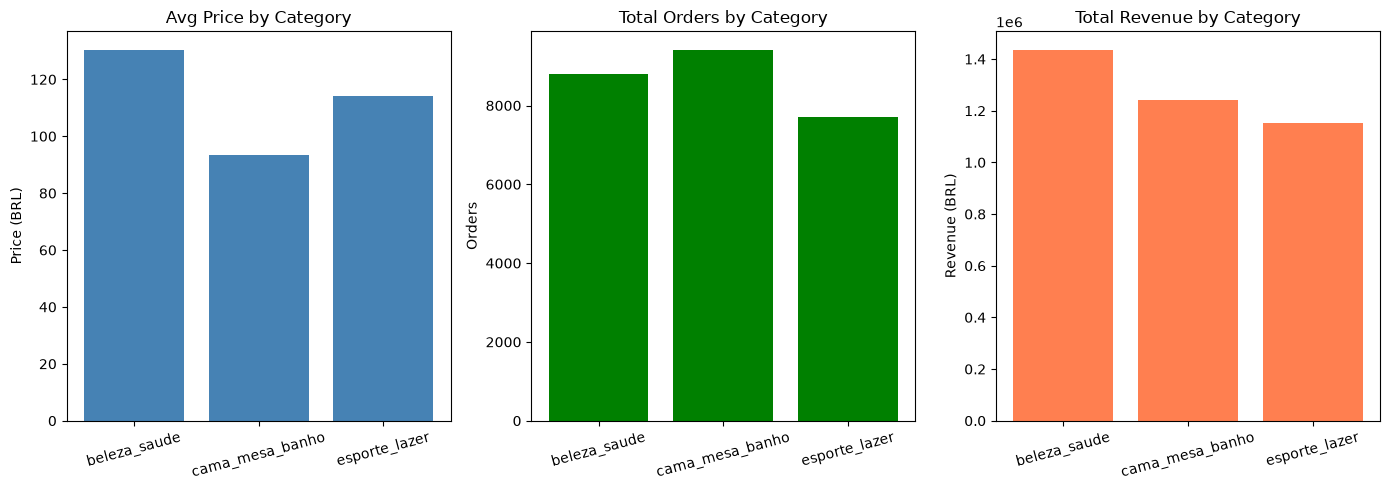

In [26]:
top_categories = df_clean.groupby('product_category_name').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('item_revenue', 'sum'),
    avg_price=('price', 'mean')
).reset_index()

top_categories = top_categories.sort_values('total_orders', ascending=False)

print("=== TOP 10 CATEGORIES BY ORDERS ===")
print(top_categories.head(10))

print("\n=== TOP 10 CATEGORIES BY REVENUE ===")
print(top_categories.sort_values('total_revenue', ascending=False).head(10))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top10_orders = top_categories.head(10)
axes[0].barh(top10_orders['product_category_name'],
             top10_orders['total_orders'], color='steelblue')
axes[0].set_title('Top 10 Categories by Orders')
axes[0].set_xlabel('Total Orders')

top10_revenue = top_categories.sort_values('total_revenue', ascending=False).head(10)
axes[1].barh(top10_revenue['product_category_name'],
             top10_revenue['total_revenue'], color='coral')
axes[1].set_title('Top 10 Categories by Revenue')
axes[1].set_xlabel('Total Revenue (BRL)')

plt.tight_layout()
plt.show()


focus_categories = ['esporte_lazer', 'cama_mesa_banho', 'beleza_saude']

comparison = df_clean[df_clean['product_category_name'].isin(focus_categories)].groupby(
    'product_category_name'
).agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('item_revenue', 'sum'),
    avg_price=('price', 'mean'),
    avg_freight=('freight_value', 'mean')
).reset_index()

print(comparison)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(comparison['product_category_name'],
            comparison['avg_price'], color='steelblue')
axes[0].set_title('Avg Price by Category')
axes[0].set_ylabel('Price (BRL)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(comparison['product_category_name'],
            comparison['total_orders'], color='green')
axes[1].set_title('Total Orders by Category')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(comparison['product_category_name'],
            comparison['total_revenue'], color='coral')
axes[2].set_title('Total Revenue by Category')
axes[2].set_ylabel('Revenue (BRL)')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

  product_category_name  total_orders  total_revenue   avg_price  avg_freight
0          beleza_saude          8791     1435611.23  130.366344    18.881107
1       cama_mesa_banho          9412     1241075.14   93.320401    18.417705
2         esporte_lazer          7701     1152729.37  114.209618    19.486667


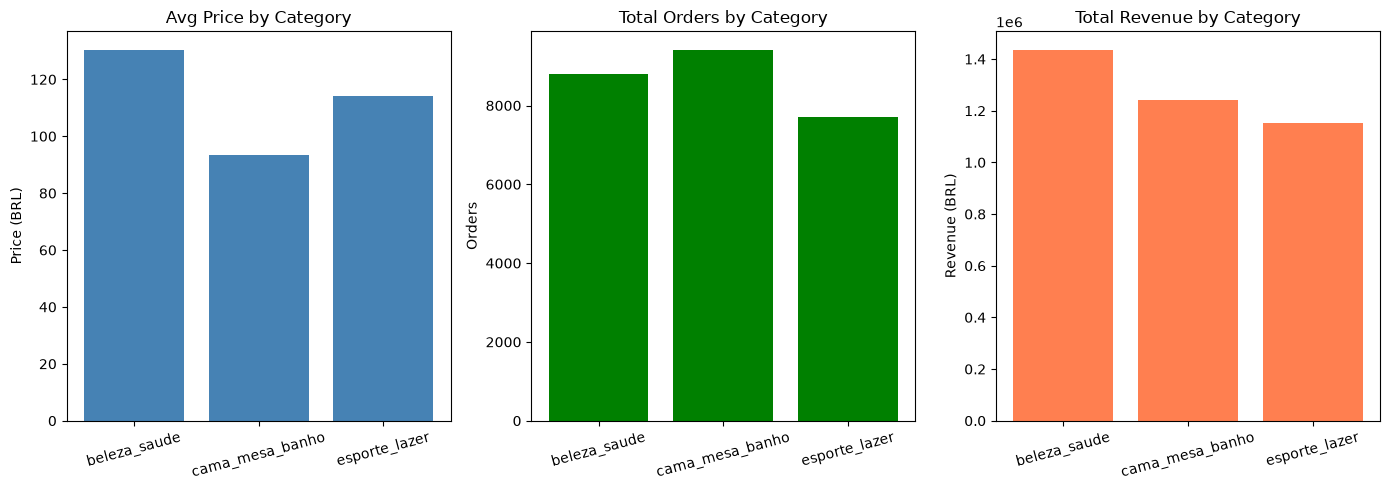

Reference date: 2018-08-31 16:13:44

RFM shape: (95774, 4)

RFM sample:
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      113          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      116          1     27.19
2  0000f46a3911fa3c0805444483337064      538          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      322          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      289          1    196.89
5  0004bd2a26a76fe21f786e4fbd80607f      147          1    166.98
6  00050ab1314c0e55a6ca13cf7181fecf      133          1     35.38
7  00053a61a98854899e70ed204dd4bafe      184          1    419.18
8  0005e1862207bf6ccc02e4228effd9a0      544          1    150.12
9  0005ef4cd20d2893f0d9fbd94d3c0d97      172          1    129.76

RFM Summary:
            recency     frequency      monetary
count  95774.000000  95774.000000  95774.000000
mean     239.178316      1.034644    164.827652
std      151.428703      0.213879    227.992

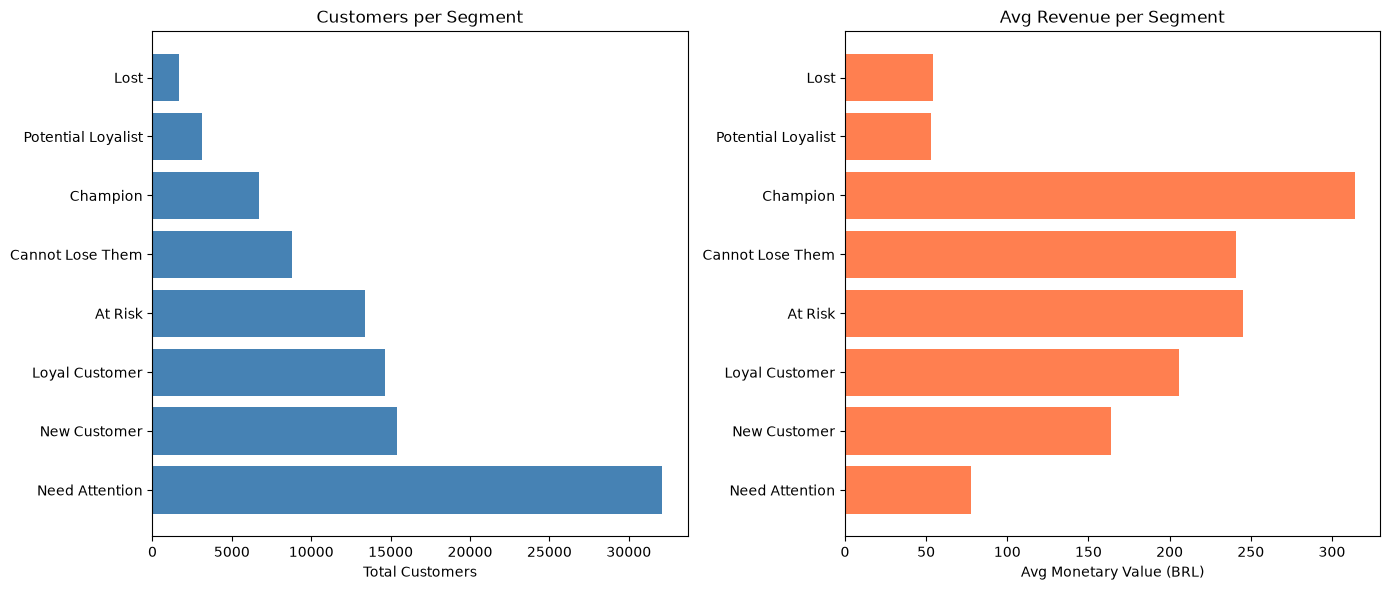

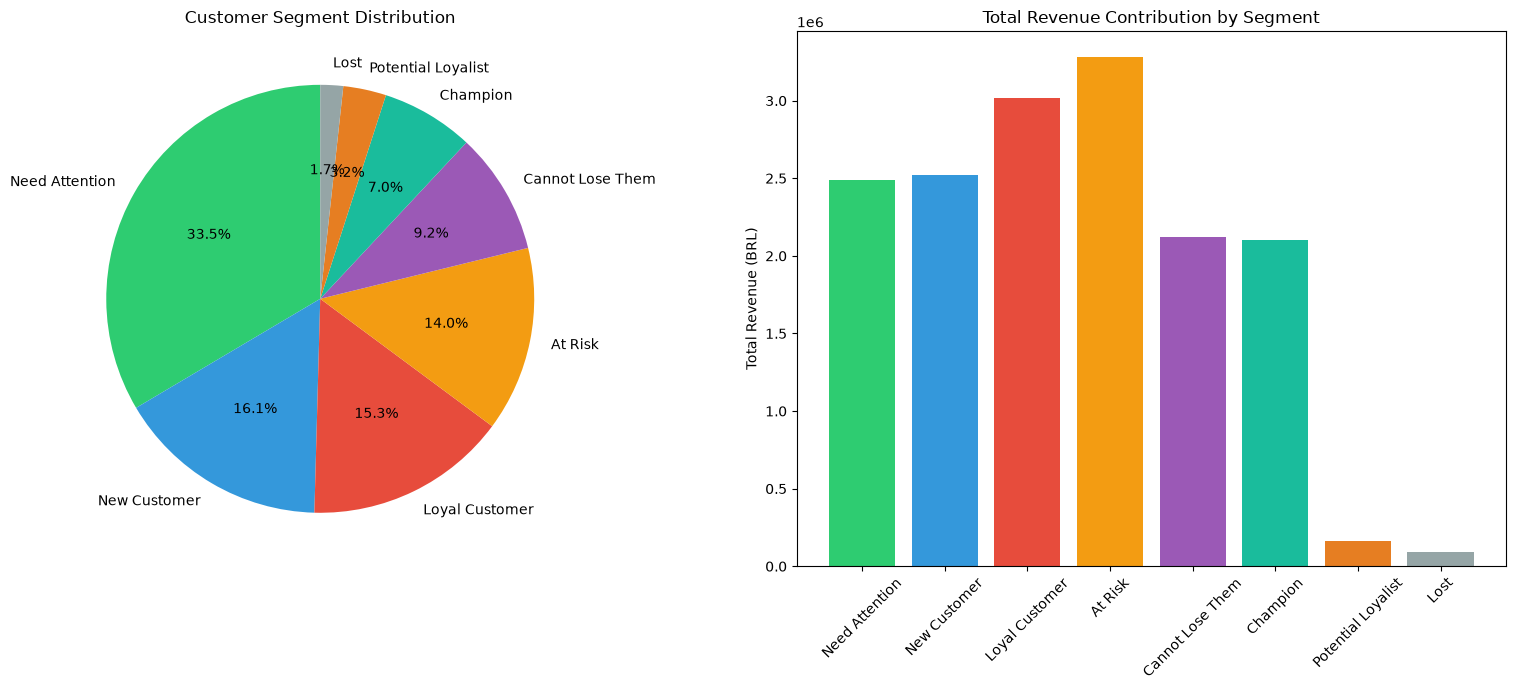

              segment  total_customers  total_revenue  revenue_pct
0             At Risk            13384     3282685.98        20.79
4      Loyal Customer            14640     3014440.18        19.10
6        New Customer            15375     2518523.47        15.95
5      Need Attention            32094     2489662.09        15.77
1    Cannot Lose Them             8819     2121761.46        13.44
2            Champion             6705     2104782.73        13.33
7  Potential Loyalist             3108      165154.56         1.05
3                Lost             1649       89193.10         0.57


In [16]:
## 3. RFM Segmentation


reference_date = df_clean['order_purchase_timestamp'].max()
print(f"Reference date: {reference_date}")

rfm = df_clean.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('item_revenue', 'sum')
).reset_index()

print(f"\nRFM shape: {rfm.shape}")
print("\nRFM sample:")
print(rfm.head(10))

print("\nRFM Summary:")
print(rfm[['recency', 'frequency', 'monetary']].describe())

rfm['r_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['rfm_score'] = (
    rfm['r_score'].astype(str) +
    rfm['f_score'].astype(str) +
    rfm['m_score'].astype(str)
)

print(rfm[['customer_unique_id', 'recency', 'frequency',
           'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score']].head(10))


def segment_customer(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Potential Loyalist'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    elif r == 1 and f == 1 and m <= 2:
        return 'Lost'
    else:
        return 'Need Attention'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

segment_summary = rfm.groupby('segment').agg(
    total_customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')          # exact sum, not approximation
).reset_index().sort_values('total_customers', ascending=False)

print(segment_summary)



colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(segment_summary['segment'],
             segment_summary['total_customers'], color='steelblue')
axes[0].set_title('Customers per Segment')
axes[0].set_xlabel('Total Customers')

axes[1].barh(segment_summary['segment'],
             segment_summary['avg_monetary'], color='coral')
axes[1].set_title('Avg Revenue per Segment')
axes[1].set_xlabel('Avg Monetary Value (BRL)')

plt.tight_layout()
plt.show()

# Pie + revenue contribution
segment_summary['revenue_pct'] = (
    segment_summary['total_revenue'] /
    segment_summary['total_revenue'].sum() * 100
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].pie(segment_summary['total_customers'],
            labels=segment_summary['segment'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[0].set_title('Customer Segment Distribution')

axes[1].bar(segment_summary['segment'],
            segment_summary['total_revenue'],
            color=colors)
axes[1].set_title('Total Revenue Contribution by Segment')
axes[1].set_ylabel('Total Revenue (BRL)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(segment_summary[['segment', 'total_customers',
                        'total_revenue', 'revenue_pct']].sort_values(
                        'total_revenue', ascending=False))

Cohort data sample:
                 customer_unique_id      first_purchase cohort_month
0  0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10 10:56:27      2018-05
1  0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07 11:11:27      2018-05
2  0000f46a3911fa3c0805444483337064 2017-03-10 21:05:03      2017-03
3  0000f6ccb0745a6a4b88665a16c9f078 2017-10-12 20:29:41      2017-10
4  0004aac84e0df4da2b147fca70cf8255 2017-11-14 19:45:42      2017-11
5  0004bd2a26a76fe21f786e4fbd80607f 2018-04-05 19:33:16      2018-04
6  00050ab1314c0e55a6ca13cf7181fecf 2018-04-20 12:57:23      2018-04
7  00053a61a98854899e70ed204dd4bafe 2018-02-28 11:15:41      2018-02
8  0005e1862207bf6ccc02e4228effd9a0 2017-03-04 23:32:12      2017-03
9  0005ef4cd20d2893f0d9fbd94d3c0d97 2018-03-12 15:22:12      2018-03

Total unique customers: 95774

Cohort months available:
cohort_month
2017-01     765
2017-02    1752
2017-03    2636
2017-04    2353
2017-05    3596
2017-06    3139
2017-07    3895
2017-08    4184
2017-09    4131
2017-10

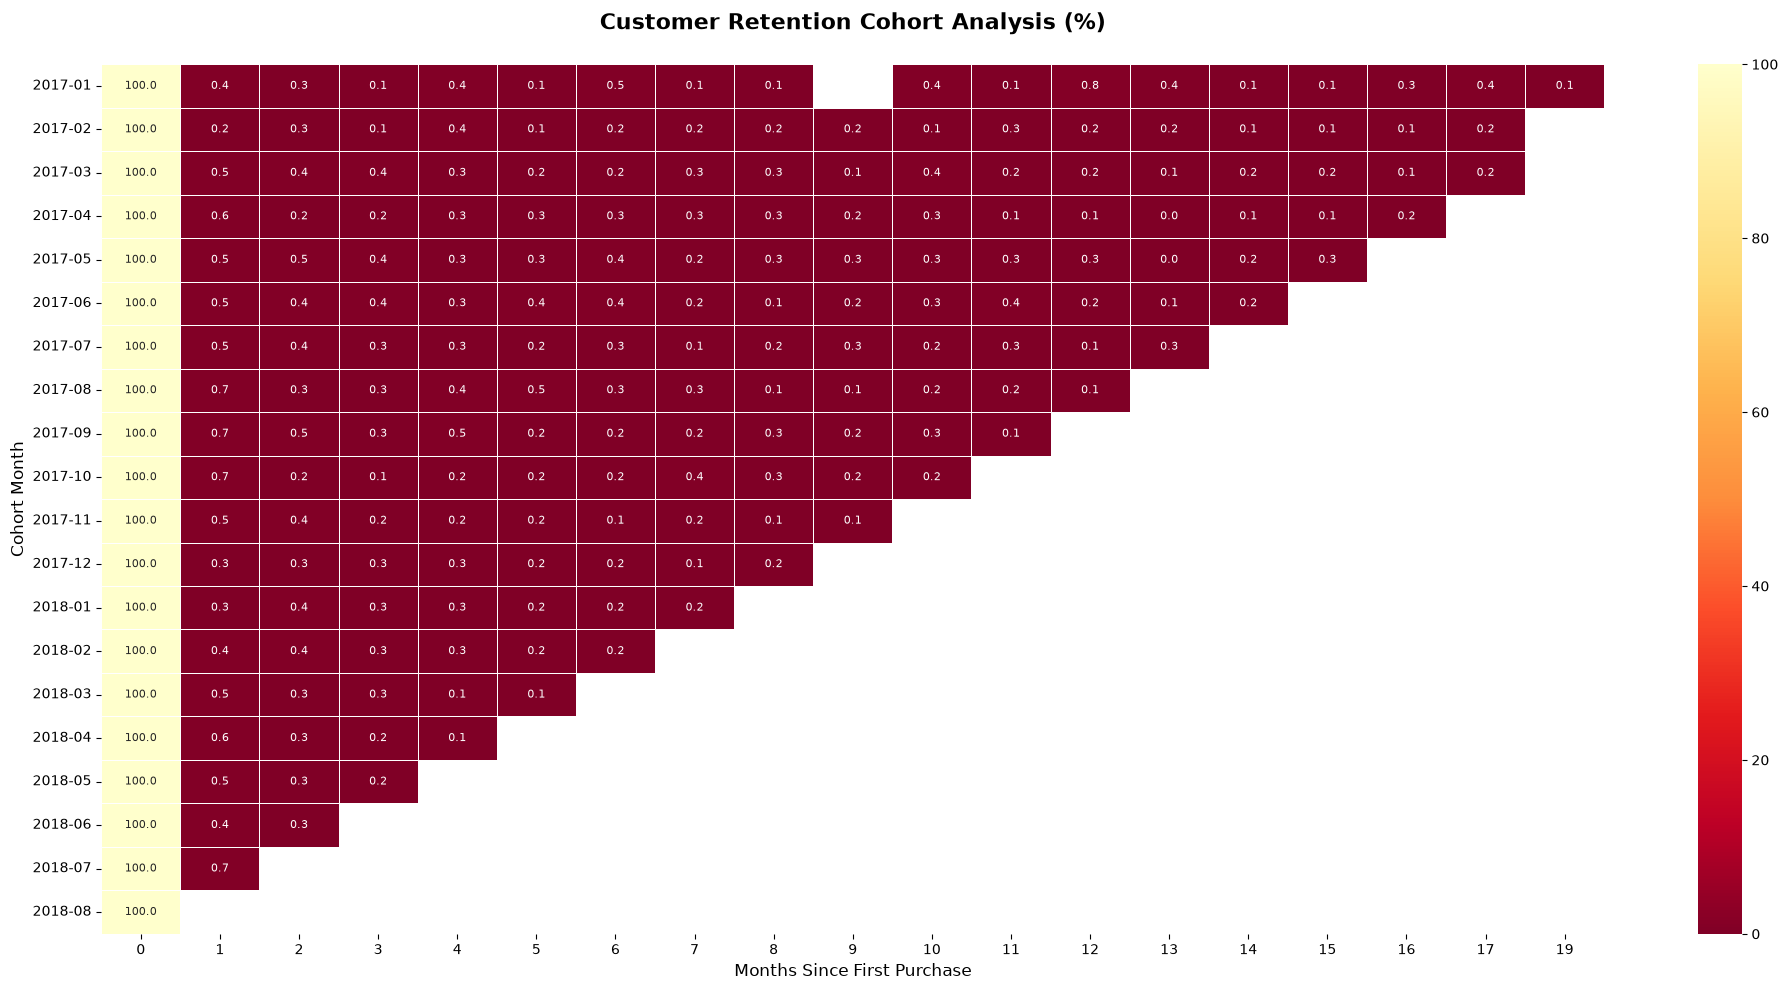


Average Retention Rate by Month:
cohort_index
0     100.00
1       0.50
2       0.34
3       0.26
4       0.29
5       0.23
6       0.26
7       0.22
8       0.21
9       0.19
10      0.27
11      0.22
12      0.25
13      0.16
14      0.15
15      0.16
16      0.18
17      0.27
19      0.10
dtype: float64


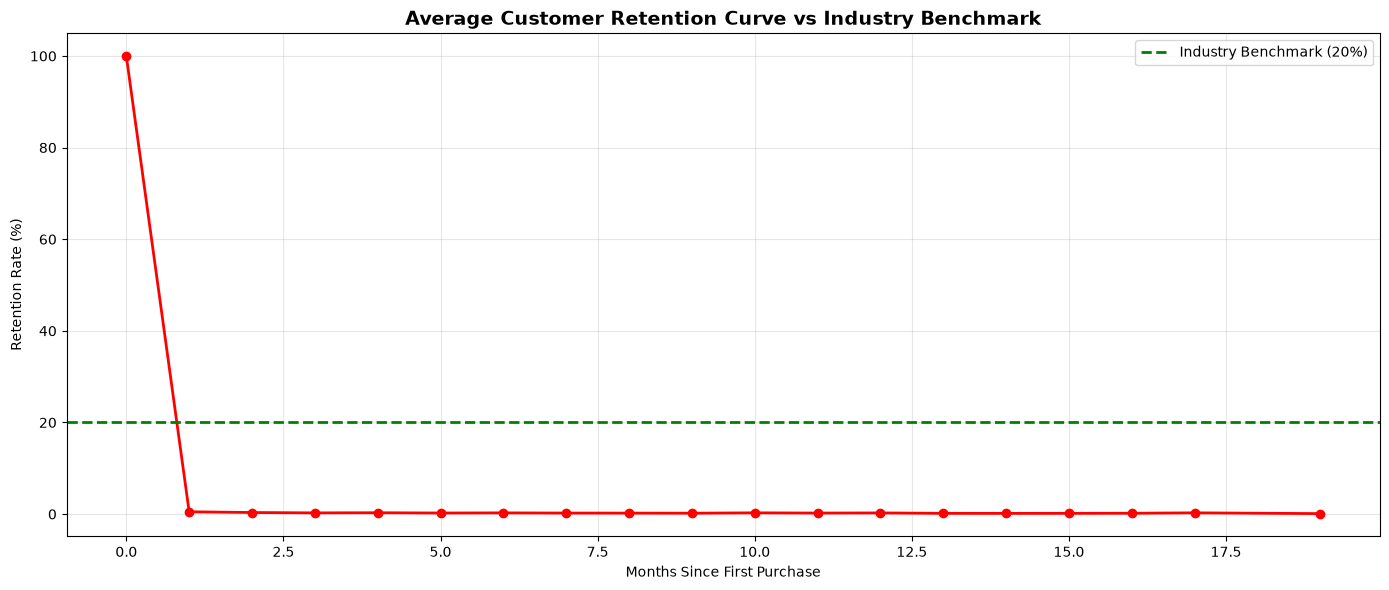

Month 1 Retention: 0.5%
Month 3 Retention: 0.26%
Month 6 Retention: 0.26%
Month 12 Retention: 0.25%

Industry Benchmark: 20–30%
Gap from benchmark at month 1: 19.50%


In [14]:
## 4. Cohort Retention Analysis

cohort_data = df_clean.groupby('customer_unique_id').agg(
    first_purchase=('order_purchase_timestamp', 'min')
).reset_index()

cohort_data['cohort_month'] = cohort_data['first_purchase'].dt.to_period('M')

print("Cohort data sample:")
print(cohort_data.head(10))
print(f"\nTotal unique customers: {cohort_data.shape[0]}")
print("\nCohort months available:")
print(cohort_data['cohort_month'].value_counts().sort_index())


# Merge cohort month back to main dataframe
df_cohort = df_clean.merge(
    cohort_data[['customer_unique_id', 'cohort_month']],
    on='customer_unique_id', how='left'
)

df_cohort['order_period'] = df_cohort['order_purchase_timestamp'].dt.to_period('M')

df_cohort['cohort_index'] = (
    df_cohort['order_period'] - df_cohort['cohort_month']
).apply(lambda x: x.n)

cohort_counts = df_cohort.groupby(
    ['cohort_month', 'cohort_index']
)['customer_unique_id'].nunique().reset_index()

cohort_matrix = cohort_counts.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

cohort_size = cohort_matrix[0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0).round(3) * 100

print("Retention Matrix (first 5 cohorts, first 6 months):")
print(retention_matrix.iloc[:5, :6])



plt.figure(figsize=(20, 10))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title('Customer Retention Cohort Analysis (%)\n', fontsize=16, fontweight='bold')
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.ylabel('Cohort Month', fontsize=12)
plt.tight_layout()
plt.show()

avg_retention = retention_matrix.mean().round(2)
print("\nAverage Retention Rate by Month:")
print(avg_retention)




avg_retention = retention_matrix.mean().round(2)

plt.figure(figsize=(14, 6))
plt.plot(avg_retention.index, avg_retention.values,
         marker='o', color='red', linewidth=2, markersize=6)
plt.axhline(y=20, color='green', linestyle='--',
            linewidth=2, label='Industry Benchmark (20%)')
plt.title('Average Customer Retention Curve vs Industry Benchmark',
          fontsize=14, fontweight='bold')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Safe print — only show months that exist in data
for month in [1, 3, 6, 12]:
    if month in avg_retention.index:
        print(f"Month {month} Retention: {avg_retention[month]}%")
    else:
        print(f"Month {month} Retention: not enough data")

print(f"\nIndustry Benchmark: 20–30%")
if 1 in avg_retention.index:
    print(f"Gap from benchmark at month 1: {20 - avg_retention[1]:.2f}%")

                       Stage  Orders  pct_of_total
0              Orders Placed   99092        100.00
1     Successfully Delivered   96211         97.09
2  Shipped but not Delivered    1097          1.11
3                  Cancelled     580          0.59
4                Unavailable     602          0.61


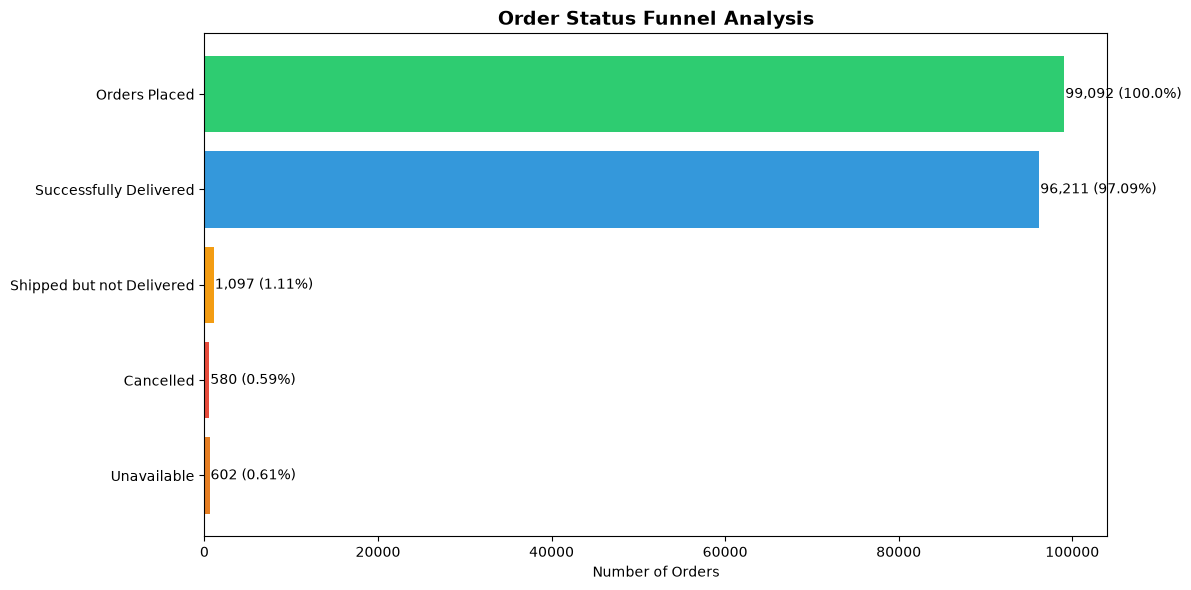

  delivery_bucket  avg_review  total_orders
0        0–7 days    4.331864         33475
1       8–14 days    4.199318         36126
2      15–21 days    4.023006         15201
3      22–30 days    3.434554          6777
4      31–60 days    2.146410          3697
5        60+ days    2.220137           271


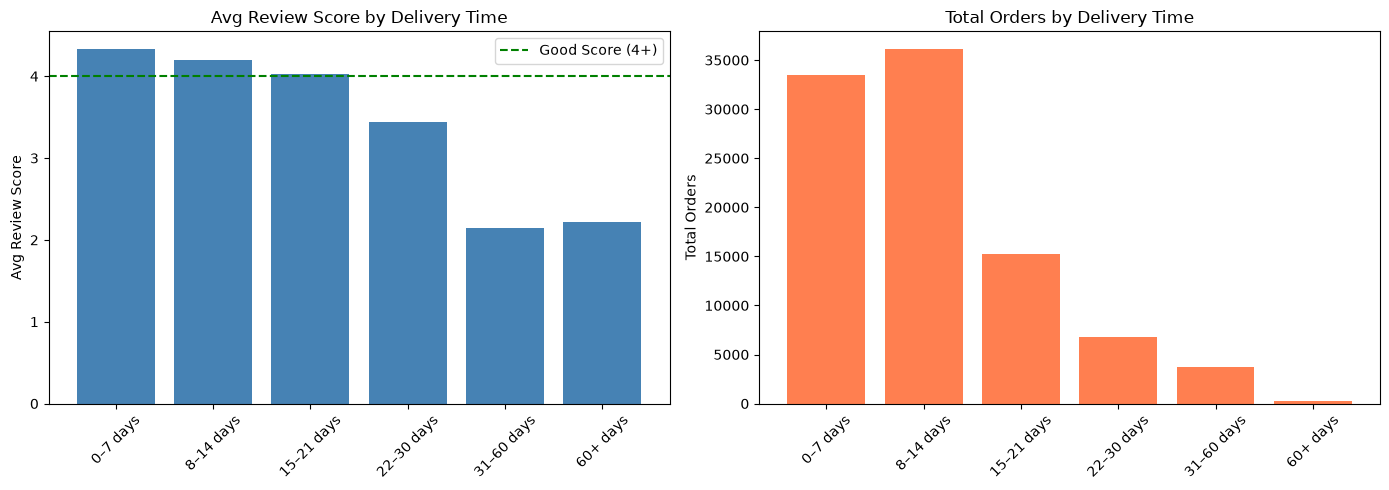

   is_late  avg_review  total_orders  avg_delivery_days
0  On Time    4.212445         87902          10.354414
1     Late    2.549448          7658          30.719051


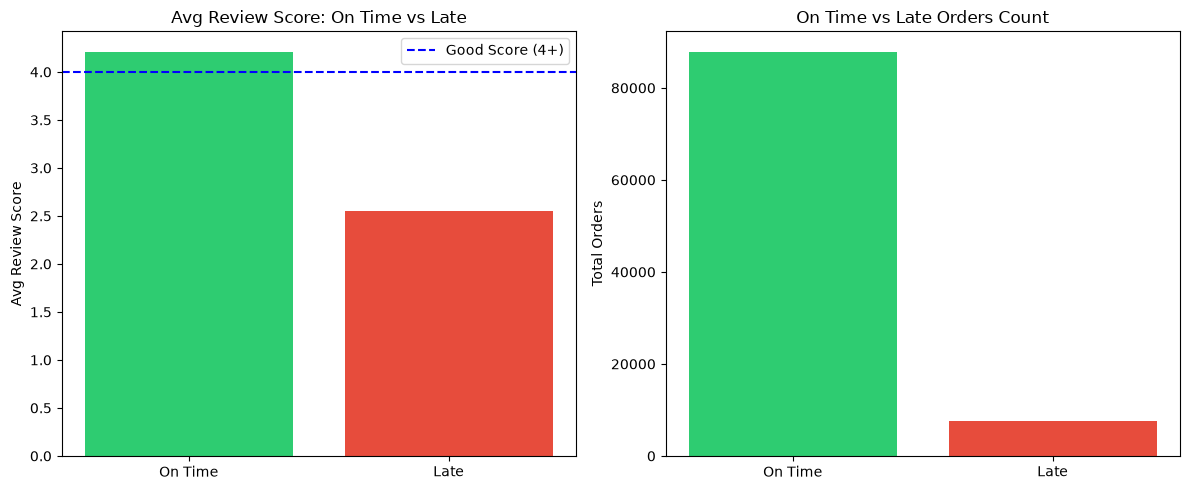

In [12]:
## 5. Funnel Analysis

funnel_stages = {
    'Orders Placed':              df_clean['order_id'].nunique(),
    'Successfully Delivered':     df_clean[df_clean['order_status'] == 'delivered']['order_id'].nunique(),
    'Shipped but not Delivered':  df_clean[df_clean['order_status'] == 'shipped']['order_id'].nunique(),
    'Cancelled':                  df_clean[df_clean['order_status'] == 'canceled']['order_id'].nunique(),
    'Unavailable':                df_clean[df_clean['order_status'] == 'unavailable']['order_id'].nunique()
}

funnel_df = pd.DataFrame(list(funnel_stages.items()), columns=['Stage', 'Orders'])
funnel_df['pct_of_total'] = (
    funnel_df['Orders'] / funnel_df['Orders'].iloc[0] * 100
).round(2)

print(funnel_df)

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#e67e22']

plt.figure(figsize=(12, 6))
bars = plt.barh(funnel_df['Stage'], funnel_df['Orders'], color=colors)

for bar, val, pct in zip(bars, funnel_df['Orders'], funnel_df['pct_of_total']):
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height() / 2,
             f'{val:,} ({pct}%)', va='center', fontsize=10)

plt.title('Order Status Funnel Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Delivery & Review Analysis

delivery_review = df_clean[
    (df_clean['order_status'] == 'delivered') &
    (df_clean['review_score'].notna()) &
    (df_clean['delivery_days'].notna())
].copy()

delivery_review['delivery_bucket'] = pd.cut(
    delivery_review['delivery_days'],
    bins=[0, 7, 14, 21, 30, 60, 999],
    labels=['0–7 days', '8–14 days', '15–21 days',
            '22–30 days', '31–60 days', '60+ days']
)

delivery_vs_review = delivery_review.groupby('delivery_bucket').agg(
    avg_review=('review_score', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

print(delivery_vs_review)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(delivery_vs_review['delivery_bucket'],
            delivery_vs_review['avg_review'], color='steelblue')
axes[0].set_title('Avg Review Score by Delivery Time')
axes[0].set_ylabel('Avg Review Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=4, color='green', linestyle='--', label='Good Score (4+)')
axes[0].legend()

axes[1].bar(delivery_vs_review['delivery_bucket'],
            delivery_vs_review['total_orders'], color='coral')
axes[1].set_title('Total Orders by Delivery Time')
axes[1].set_ylabel('Total Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


late_analysis = delivery_review.groupby('is_late').agg(
    avg_review=('review_score', 'mean'),
    total_orders=('order_id', 'nunique'),
    avg_delivery_days=('delivery_days', 'mean')
).reset_index()

late_analysis['is_late'] = late_analysis['is_late'].map({0: 'On Time', 1: 'Late'})

print(late_analysis)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(late_analysis['is_late'],
            late_analysis['avg_review'],
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Avg Review Score: On Time vs Late')
axes[0].set_ylabel('Avg Review Score')
axes[0].axhline(y=4, color='blue', linestyle='--', label='Good Score (4+)')
axes[0].legend()

axes[1].bar(late_analysis['is_late'],
            late_analysis['total_orders'],
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title('On Time vs Late Orders Count')
axes[1].set_ylabel('Total Orders')

plt.tight_layout()
plt.show()

In [25]:
# Export clean master dataframe for Power BI
df_clean.to_csv('../data/olist_master_clean.csv', index=False)

# Export RFM segments
rfm.to_csv('../data/olist_rfm_segments.csv', index=False)

# Export monthly revenue
monthly_revenue.to_csv('../data/olist_monthly_revenue.csv', index=False)

# Export segment summary
segment_summary.to_csv('../data/olist_segment_summary.csv', index=False)

print("All files exported successfully! ✅")

# Export retention matrix for Power BI
retention_matrix.to_csv('../data/olist_retention_matrix.csv')

# Export delivery vs review (recreate properly)
delivery_review = df_clean[
    (df_clean['order_status'] == 'delivered') &
    (df_clean['review_score'].notna()) &
    (df_clean['delivery_days'].notna())
].copy()

delivery_review['delivery_bucket'] = pd.cut(
    delivery_review['delivery_days'],
    bins=[0, 7, 14, 21, 30, 60, 999],
    labels=['0-7 days', '8-14 days', '15-21 days', 
            '22-30 days', '31-60 days', '60+ days']
)

delivery_vs_review = delivery_review.groupby('delivery_bucket').agg(
    avg_review=('review_score', 'mean'),
    total_orders=('order_id', 'nunique')
).reset_index()

delivery_vs_review.to_csv('../data/olist_delivery_review.csv', index=False)

print("Delivery review file exported! ✅")

print("Cohort and delivery files exported! ✅")


import os
files = os.listdir('../data/')
print(files)



retention_long = retention_matrix.reset_index().melt(
    id_vars='cohort_month',
    var_name='cohort_index',
    value_name='retention_pct'
)

retention_long.to_csv('../data/olist_retention_long.csv', index=False)
print("Long format retention exported! ✅")

All files exported successfully! ✅
Delivery review file exported! ✅
Cohort and delivery files exported! ✅
['E-commerce Customer Behavior Analytics Project Final.ipynb', 'olist_sellers_dataset.csv', 'Script.sql', 'Untitled1.ipynb', '.DS_Store', 'product_category_name_translation.csv', 'archive', 'E-commerce Customer Behavior Analytics Project.ipynb', 'Untitled.ipynb', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'customer_sales_analysis.sql', 'olist_retention_matrix.csv', 'olist_segment_summary.csv', 'olist ecommerce final project.sql', 'data warehouse.sql', 'olist_monthly_revenue.csv', 'olist_master_clean.csv', 'olist_delivery_review.csv', 'Script-3.sql', 'olist_customers_dataset.csv', 'Script-4.sql', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', '.ipynb_checkpoints', 'olist_rfm_segments.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']
Long format retention exported! ✅
